#### Import libraries

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

In [ ]:
!pip install tensorflow


In [74]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#### Create Dataset

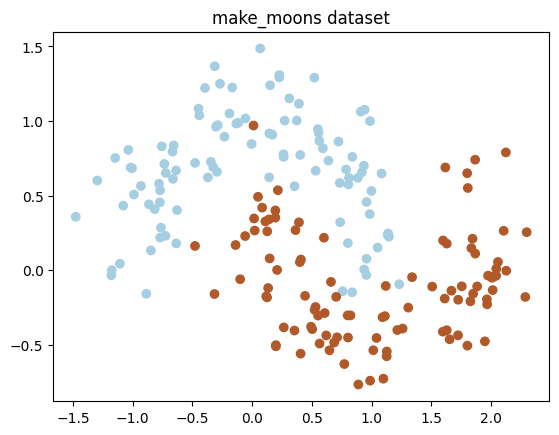

In [75]:
# Generate dataset
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

# Plot dataset
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.Paired)
plt.title("make_moons dataset")
plt.show()


#### Split into Train, Validation, Test

In [76]:
# Split into train, val, test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

#### Build Neural Network

In [77]:
model = Sequential([
    Dense(3, activation='relu', input_shape=(2,)),  # hidden layer with 3 neurons
    Dense(1, activation='sigmoid')                  # output layer (binary classification)
])


#### Compile Model

In [78]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


#### Train Model

In [79]:
# Fit model using validation set
history = model.fit(X_train, y_train, epochs=150, validation_data=(X_val, y_val), verbose=0)

#### Evaluate Model

In [80]:
# Accuracy on training data
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
print(f"Train Accuracy: {train_acc:.2f}")

# Accuracy on test data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.2f}")


Train Accuracy: 0.86
Test Accuracy: 0.85


In [39]:
dir(history.history)

['__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__ior__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__ne__',
 '__new__',
 '__or__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__reversed__',
 '__ror__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'clear',
 'copy',
 'fromkeys',
 'get',
 'items',
 'keys',
 'pop',
 'popitem',
 'setdefault',
 'update',
 'values']

#### Plot Training History

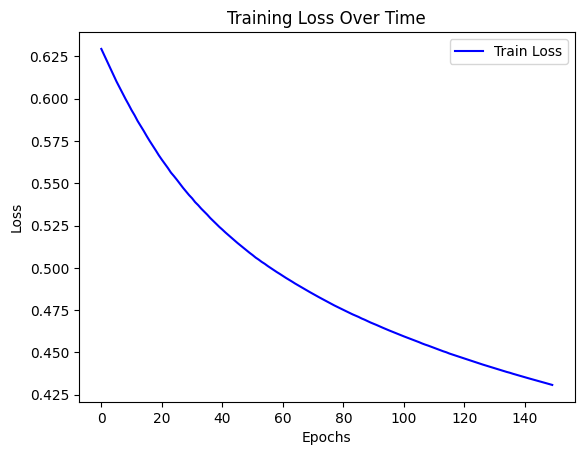

In [81]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.legend()
plt.show()


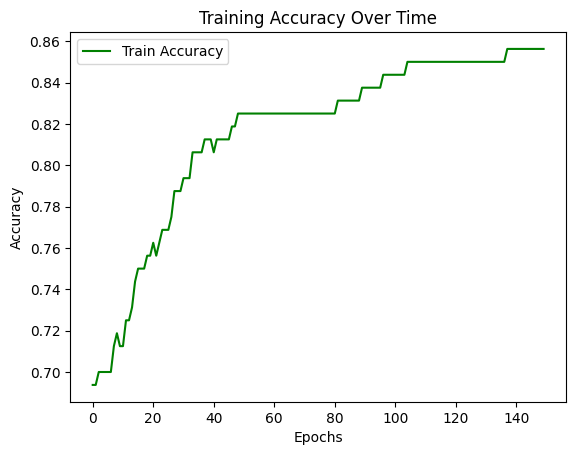

In [82]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy', color='green')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy Over Time')
plt.show()


In [83]:
#### change model retrain
model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])


In [84]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [85]:
# Fit model using validation set
history = model.fit(X_train, y_train, epochs=150, validation_data=(X_val, y_val), verbose=0)

In [86]:
# Accuracy on training data
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
print(f"Train Accuracy: {train_acc:.2f}")

# Accuracy on test data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.2f}")


Train Accuracy: 0.91
Test Accuracy: 0.85


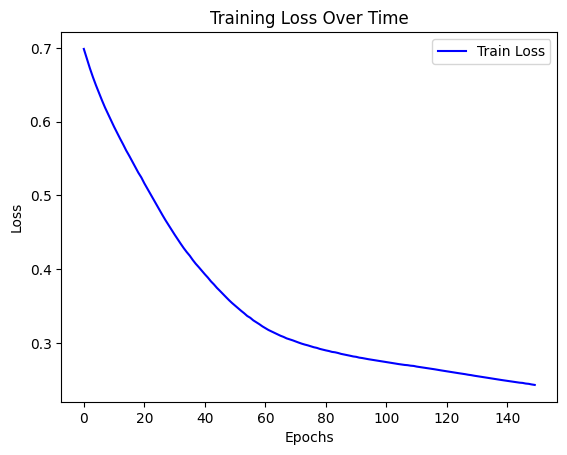

In [87]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.legend()
plt.show()


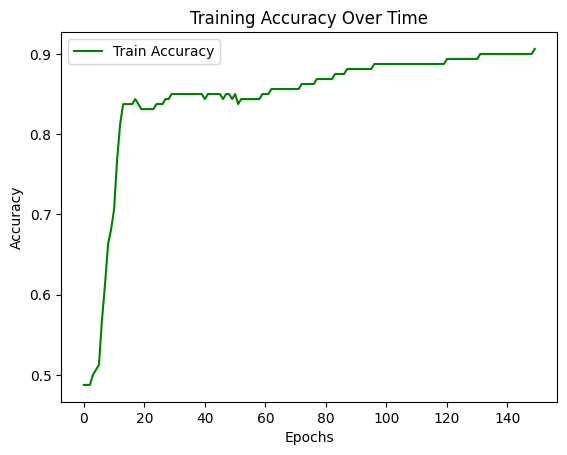

In [88]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy', color='green')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy Over Time')
plt.show()


#### Train vs Validation Accuracy Plot

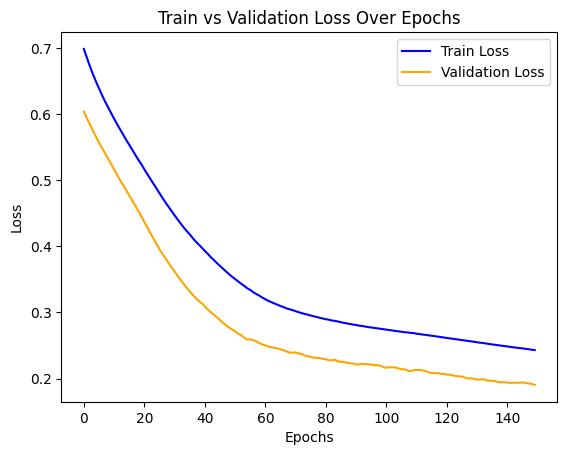

In [89]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss Over Epochs')
plt.legend()
plt.show()


#### Train vs Validation Accuracy Plot

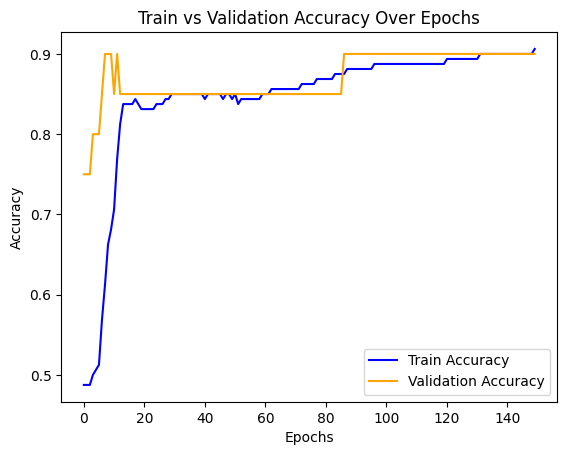

In [90]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy Over Epochs')
plt.legend()
plt.show()


#### Decision Boundary

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step


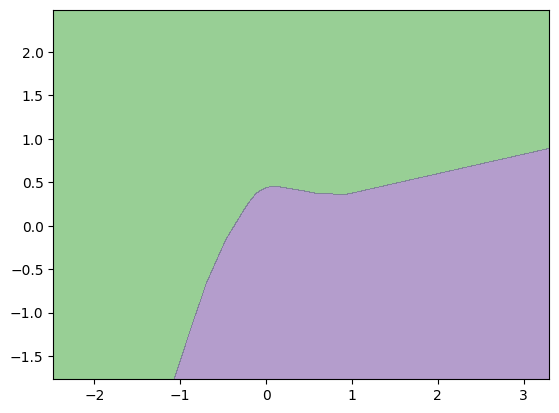

In [91]:
# Create a grid of points
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Predict on grid
preds = model.predict(grid).reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, preds, levels=[0,0.5,1], cmap=plt.cm.Paired, alpha=0.5)
